In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import re

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "raw" / "customer_support_tickets.csv"

print(DATA_PATH)

/home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /data/raw/customer_support_tickets.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [43]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [48]:
print(df["Ticket Description"].iloc[0],"new lines")
print(df["Ticket Description"].iloc[1],"new lines")
print(df["Ticket Description"].iloc[2])

I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists. new lines
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly. new lines
I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.


In [50]:
df.nunique().sort_values(ascending=False)

Ticket ID                       8469
Customer Email                  8320
Ticket Description              8077
Customer Name                   8028
clean_text                      7992
clean_text_no_stopwords         7922
First Response Time             5470
Resolution                      2769
Time to Resolution              2728
Date of Purchase                 730
text_length                      223
Customer Age                      53
word_count                        43
Product Purchased                 42
Ticket Subject                    16
Customer Satisfaction Rating       5
Ticket Type                        5
Ticket Channel                     4
Ticket Priority                    4
Customer Gender                    3
Ticket Status                      3
dtype: int64

In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [56]:
df["Resolution"].value_counts()

Resolution
Case maybe show recently my computer follow.            1
Try capital clearly never color toward story.           1
West decision evidence bit.                             1
Measure tonight surface feel forward.                   1
Measure there house management pick knowledge trade.    1
                                                       ..
Interesting show must successful.                       1
Skill expect admit and.                                 1
Say position key appear behavior.                       1
Eight account century nature kitchen.                   1
We seat culture plan.                                   1
Name: count, Length: 2769, dtype: int64

In [6]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
df.head(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
5,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
6,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
7,8,Denise Lee,joelwilliams@example.com,23,Male,Philips Hue Lights,2020-08-09,Refund request,Battery life,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Social media,NaN,NaN,NaN
8,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
9,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


In [8]:
def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [10]:
df["clean_text"] = df["Ticket Description"].apply(clean_text)

In [11]:
df[["Ticket Description","clean_text"]].head(10)

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
1,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
2,I'm facing a problem with my {product_purchase...,i m facing a problem with my product purchased...
3,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
4,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
5,I'm facing a problem with my {product_purchase...,i m facing a problem with my product purchased...
6,I'm unable to access my {product_purchased} ac...,i m unable to access my product purchased acco...
7,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
8,I'm having an issue with the {product_purchase...,i m having an issue with the product purchased...
9,My {product_purchased} is making strange noise...,my product purchased is making strange noises ...


In [12]:
df["text_length"] = df["clean_text"].str.len()

In [14]:
df["text_length"].describe()

count    8469.000000
mean      273.839414
std        45.872953
min       145.000000
25%       253.000000
50%       284.000000
75%       305.000000
max       381.000000
Name: text_length, dtype: float64

In [15]:
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

In [16]:
df["word_count"].describe()

count    8469.000000
mean       50.280907
std         8.861667
min        24.000000
25%        46.000000
50%        53.000000
75%        57.000000
max        66.000000
Name: word_count, dtype: float64

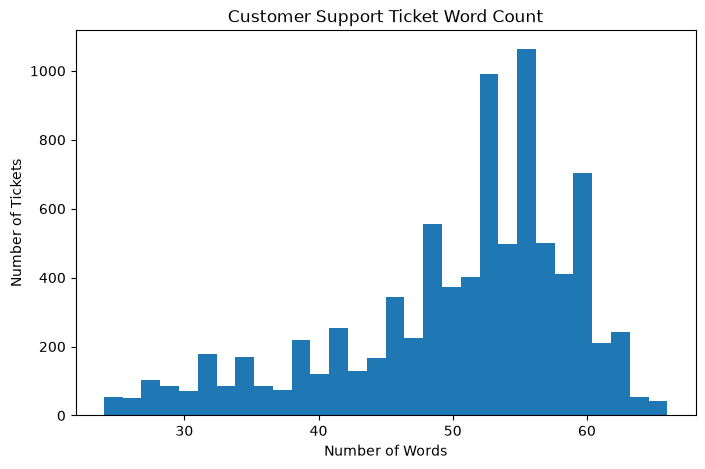

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=30)

plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.title("Customer Support Ticket Word Count")

plt.show()

In [18]:
all_words = []

for text in df["clean_text"]:
    all_words.extend(text.split())

print("Total words:", len(all_words))

Total words: 425829


In [19]:
all_words 

['i',
 'm',
 'having',
 'an',
 'issue',
 'with',
 'the',
 'product',
 'purchased',
 'please',
 'assist',
 'your',
 'billing',
 'zip',
 'code',
 'is',
 'we',
 'appreciate',
 'that',
 'you',
 'have',
 'requested',
 'a',
 'website',
 'address',
 'please',
 'double',
 'check',
 'your',
 'email',
 'address',
 'i',
 've',
 'tried',
 'troubleshooting',
 'steps',
 'mentioned',
 'in',
 'the',
 'user',
 'manual',
 'but',
 'the',
 'issue',
 'persists',
 'i',
 'm',
 'having',
 'an',
 'issue',
 'with',
 'the',
 'product',
 'purchased',
 'please',
 'assist',
 'if',
 'you',
 'need',
 'to',
 'change',
 'an',
 'existing',
 'product',
 'i',
 'm',
 'having',
 'an',
 'issue',
 'with',
 'the',
 'product',
 'purchased',
 'please',
 'assist',
 'if',
 'the',
 'issue',
 'i',
 'm',
 'facing',
 'is',
 'intermittent',
 'sometimes',
 'it',
 'works',
 'fine',
 'but',
 'other',
 'times',
 'it',
 'acts',
 'up',
 'unexpectedly',
 'i',
 'm',
 'facing',
 'a',
 'problem',
 'with',
 'my',
 'product',
 'purchased',
 'the',

In [20]:
word_counts = Counter(all_words)

word_counts.most_common(20)

[('the', 26455),
 ('i', 22520),
 ('product', 16985),
 ('purchased', 14451),
 ('issue', 11532),
 ('to', 10826),
 ('m', 10343),
 ('my', 9602),
 ('please', 8815),
 ('it', 8747),
 ('with', 8328),
 ('an', 7252),
 ('a', 6902),
 ('having', 6430),
 ('assist', 6258),
 ('ve', 6120),
 ('and', 6022),
 ('is', 5679),
 ('you', 4770),
 ('but', 4385)]

In [21]:
word_frequency = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

word_frequency

,Word,Frequency
0,the,26455
1,i,22520
2,product,16985
3,purchased,14451
4,issue,11532
5,to,10826
6,m,10343
7,my,9602
8,please,8815
9,it,8747


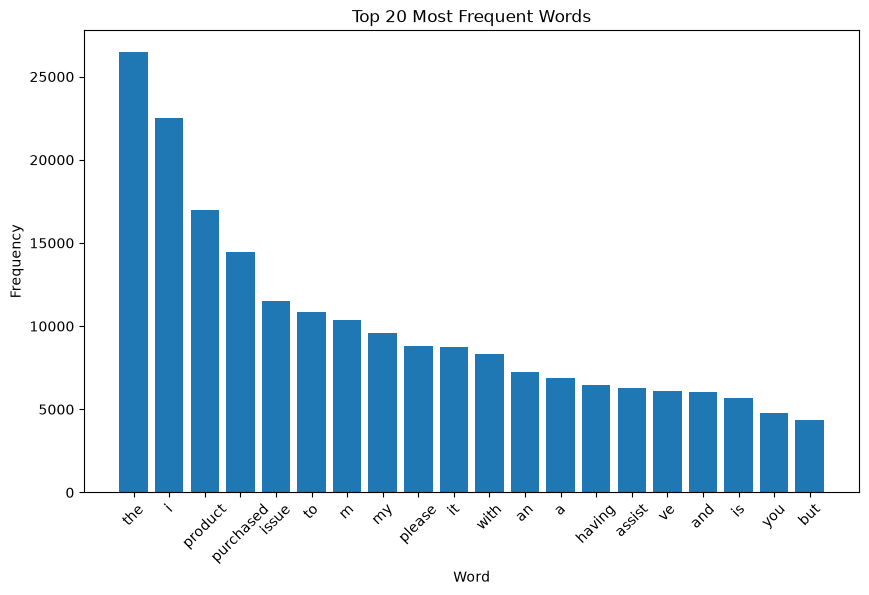

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(
    word_frequency["Word"],
    word_frequency["Frequency"]
)

plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.show()

In [23]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

["hasn't", 'be', "aren't", "haven't", 'himself', "weren't", 'or', 'own', 'yourselves', 'him', "he'll", 'his', 'there', 've', "we'll", 'up', 'aren', "it's", 'didn', 'not']


In [24]:
def remove_stopwords(text):
    words = text.split()
    
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)

In [25]:
df["clean_text_no_stopwords"] = df["clean_text"].apply(
    remove_stopwords
)

In [26]:
df["clean_text_no_stopwords"]

0       issue product purchased please assist billing ...
1       issue product purchased please assist need cha...
2       facing problem product purchased product purch...
3       issue product purchased please assist problem ...
4       issue product purchased please assist note sel...
                              ...                        
8464    product purchased making strange noises functi...
8465    issue product purchased please assist sell als...
8466    issue product purchased please assist using di...
8467    issue product purchased please assist think pr...
8468    seems hardware problem product purchased scree...
Name: clean_text_no_stopwords, Length: 8469, dtype: str

In [27]:
df[
    ["clean_text", "clean_text_no_stopwords"]
].head(10)  

,clean_text,clean_text_no_stopwords
0,i m having an issue with the product purchased...,issue product purchased please assist billing ...
1,i m having an issue with the product purchased...,issue product purchased please assist need cha...
2,i m facing a problem with my product purchased...,facing problem product purchased product purch...
3,i m having an issue with the product purchased...,issue product purchased please assist problem ...
4,i m having an issue with the product purchased...,issue product purchased please assist note sel...
5,i m facing a problem with my product purchased...,facing problem product purchased product purch...
6,i m unable to access my product purchased acco...,unable access product purchased account keeps ...
7,i m having an issue with the product purchased...,issue product purchased please assist thanks c...
8,i m having an issue with the product purchased...,issue product purchased please assist thank pr...
9,my product purchased is making strange noises ...,product purchased making strange noises functi...


In [28]:
all_words_no_stopwords = []

for text in df["clean_text_no_stopwords"]:
    all_words_no_stopwords.extend(text.split())

word_counts_no_stopwords = Counter(all_words_no_stopwords)

word_frequency_no_stopwords = pd.DataFrame(
    word_counts_no_stopwords.most_common(20),
    columns=["Word", "Frequency"]
)

word_frequency_no_stopwords

,Word,Frequency
0,product,16985
1,purchased,14451
2,issue,11532
3,please,8815
4,assist,6258
5,problem,2285
6,data,1667
7,software,1555
8,account,1468
9,steps,1390


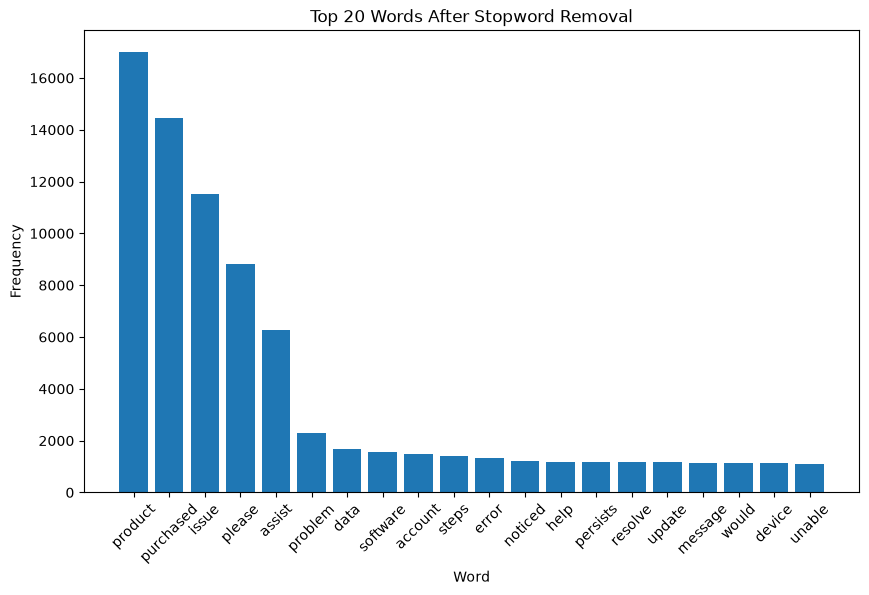

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    word_frequency_no_stopwords["Word"],
    word_frequency_no_stopwords["Frequency"]
)

plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Words After Stopword Removal")

plt.show()

In [30]:
# Bigrams

from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2)
)

bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text_no_stopwords"]
)

bigram_counts = np.asarray(
    bigram_matrix.sum(axis=0)
).ravel()

bigram_names = bigram_vectorizer.get_feature_names_out()

In [31]:
bigram_frequency = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
})

bigram_frequency = bigram_frequency.sort_values(
    by="Frequency",
    ascending=False
)

bigram_frequency.head(20)

,Bigram,Frequency
28762,product purchased,14247
18143,issue product,6333
26858,please assist,6247
30076,purchased please,6121
18128,issue persists,1176
30001,purchased issue,996
11942,error message,972
32285,resolve problem,747
39878,troubleshooting steps,684
3307,assist product,650


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer()

In [33]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

In [34]:
X_tfidf = tfidf_vectorizer.fit_transform(
    df["clean_text_no_stopwords"]
)

In [35]:
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (8469, 3000)


In [36]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))

print(feature_names[:50])

Number of features: 3000
['able' 'able find' 'able get' 'able make' 'able purchase' 'able see'
 'able sell' 'able use' 'absolutely' 'accept' 'accepted' 'access'
 'access account' 'access product' 'accidentally' 'accidentally deleted'
 'account' 'account account' 'account already' 'account checked'
 'account click' 'account concerned' 'account experiencing'
 'account followed' 'account get' 'account id' 'account keeps'
 'account locked' 'account log' 'account login' 'account manager'
 'account may' 'account name' 'account need' 'account new'
 'account noticed' 'account number' 'account open' 'account password'
 'account performed' 'account please' 'account problem' 'account product'
 'account recently' 'account recover' 'account reset' 'account reviewed'
 'account says' 'account simply' 'account step']


In [38]:
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,clean_text,text_length,word_count,clean_text_no_stopwords
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,i m having an issue with the product purchased...,265,45,issue product purchased please assist billing ...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,i m having an issue with the product purchased...,267,49,issue product purchased please assist need cha...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,i m facing a problem with my product purchased...,256,48,facing problem product purchased product purch...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,i m having an issue with the product purchased...,253,46,issue product purchased please assist problem ...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,i m having an issue with the product purchased...,321,59,issue product purchased please assist note sel...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,...,NaN,Low,Phone,NaN,NaN,NaN,my product purchased is making strange noises ...,284,50,product purchased making strange noises functi...
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,...,NaN,Critical,Email,NaN,NaN,NaN,i m having an issue with the product purchased...,219,43,issue product purchased please assist sell als...
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,...,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0,i m having an issue with the product purchased...,227,44,issue product purchased please assist using di...
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,...,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0,i m having an issue with the product purchased...,303,59,issue product purchased please assist think pr...


In [39]:
X = df["clean_text_no_stopwords"]
y = df["Ticket Type"]

In [40]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [41]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

In [61]:
X_train_tfidf = tfidf_vectorizer.fit_transform(
    X_train_text
)

In [62]:
X_test_tfidf = tfidf_vectorizer.transform(
    X_test_text
)

In [63]:
print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (6775, 3000)
Testing TF-IDF: (1694, 3000)


In [64]:
from sklearn.linear_model import LogisticRegression

text_model = LogisticRegression(
    max_iter=1000
)

In [65]:
text_model.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [66]:
y_pred = text_model.predict(X_test_tfidf)

In [67]:
y_pred

array(['Cancellation request', 'Refund request', 'Cancellation request',
       ..., 'Cancellation request', 'Refund request', 'Refund request'],
      shape=(1694,), dtype=object)

In [69]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

In [70]:
accuracy

0.2089728453364817

In [71]:
precision

0.20924628885286597

In [72]:
f1

0.20899181255123134

In [73]:
recall

0.2089728453364817

In [74]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.2089728453364817
Precision: 0.20924628885286597
Recall   : 0.2089728453364817
F1 Score : 0.20899181255123134


In [75]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.22      0.22       327
Cancellation request       0.20      0.19      0.20       339
     Product inquiry       0.21      0.22      0.21       328
      Refund request       0.20      0.21      0.20       351
     Technical issue       0.22      0.21      0.22       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



In [76]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71 60 67 74 55]
 [64 66 69 80 60]
 [58 69 72 62 67]
 [70 69 70 72 70]
 [66 64 70 76 73]]


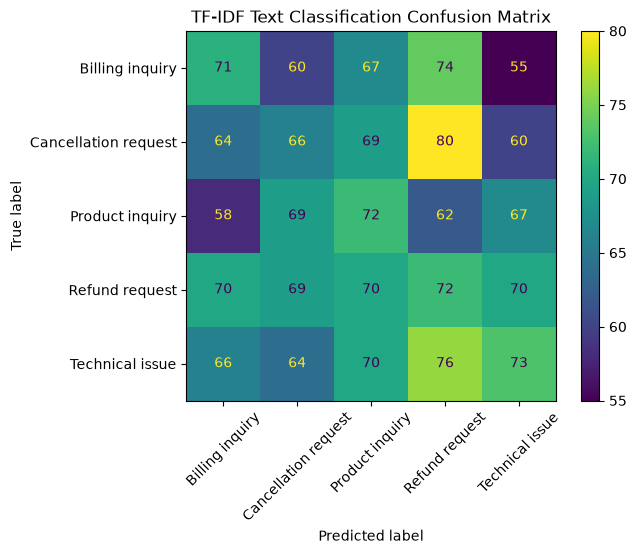

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("TF-IDF Text Classification Confusion Matrix")
plt.show()

In [96]:
nlp_results_logistics = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})

nlp_results

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.208973,0.209246,0.208973,0.208992


In [84]:
from sklearn.naive_bayes import MultinomialNB

In [85]:
naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = naive_bayes_model.predict(
    X_test_tfidf
)

In [86]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

In [87]:
nb_accuracy

0.21074380165289255

In [88]:
nb_precision

0.21038541330235538

In [89]:
nb_recall

0.21074380165289255

In [90]:
nb_f1

0.21025436910964299

In [93]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.17      0.19       327
Cancellation request       0.20      0.20      0.20       339
     Product inquiry       0.21      0.22      0.22       328
      Refund request       0.20      0.21      0.20       351
     Technical issue       0.24      0.25      0.24       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



In [94]:
cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[56 57 73 80 61]
 [59 68 63 82 67]
 [50 65 72 71 70]
 [56 69 72 74 80]
 [57 82 56 67 87]]


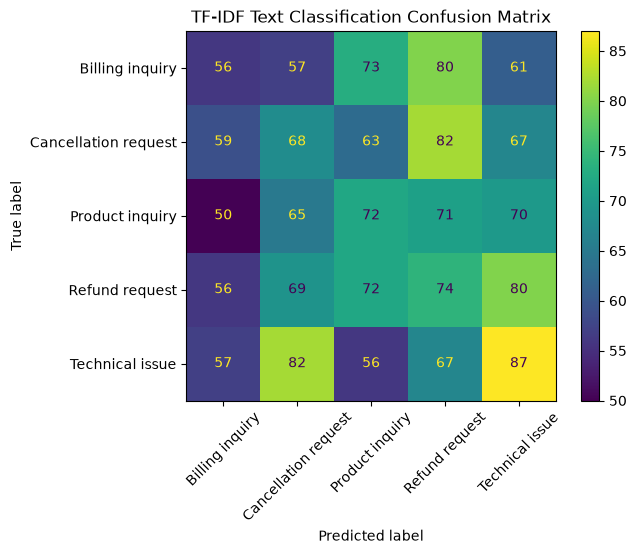

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    xticks_rotation=45
)

plt.title("TF-IDF Text Classification Confusion Matrix")
plt.show()

In [97]:
nlp_results_naive_bayes = pd.DataFrame({
    "Model": ["TF-IDF + Naive Bayes"],
    "Accuracy": [nb_accuracy],
    "Precision": [nb_precision],
    "Recall": [nb_recall],
    "F1": [nb_f1]
})

nlp_results_naive_bayes

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Naive Bayes,0.210744,0.210385,0.210744,0.210254


In [98]:
nlp_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy
    ],
    "Precision": [
        precision,
        nb_precision
    ],
    "Recall": [
        recall,
        nb_recall
    ],
    "F1": [
        f1,
        nb_f1
    ]
})

nlp_results

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.208973,0.209246,0.208973,0.208992
1,TF-IDF + Naive Bayes,0.210744,0.210385,0.210744,0.210254


In [99]:
RESULT_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "nlp_model_results.csv"
)

nlp_results.to_csv(
    RESULT_PATH,
    index=False
)

print("Saved:", RESULT_PATH)

Saved: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /data/processed/nlp_model_results.csv


In [101]:
import joblib

joblib.dump(
    tfidf_vectorizer,
    BASE_DIR / "models" / "tfidf_vectorizer.pkl"
)

joblib.dump(
    text_model,
    BASE_DIR / "models" / "logistic_text_model.pkl"
)

joblib.dump(
    naive_bayes_model,
    BASE_DIR / "models" / "naive_bayes_text_model.pkl"
)

print("All NLP models saved successfully.")

All NLP models saved successfully.


In [105]:
df.to_csv(
    BASE_DIR / "data" / "processed" / "customer_support_tickets_processed_NLP.csv",
    index=False
)